In [10]:
2+2

4

In [11]:
import numpy as np
from typing import Union, Tuple, Optional, List
from draw import draw_dot
from typing import Union

TensorLike = Union[
    'Tensor',
    int,
    float,
    list,
    tuple,
    np.ndarray,
    np.number
]

In [172]:
class Tensor:
    def __init__(
        self,
        data: Union['Tensor',np.ndarray,float,int,list],
        requires_grad: bool = False,
        is_leaf: bool = True,
        dtype: np.dtype = np.float32,
        
    ):
        
        if not isinstance(requires_grad, bool):
            raise TypeError(
                f"requires_grad must be bool, got {type(requires_grad).__name__}"
            )

        if not isinstance(is_leaf, bool):
            raise TypeError(
                f"is_leaf must be bool, got {type(is_leaf).__name__}"
            )
        
        if isinstance(data, Tensor):
            data = data.data

        try:
            self.data = np.array(data, dtype=dtype)
        except Exception:
            raise TypeError(
                f"Unsupported data type: {type(data)}"
            )

        self.requires_grad = requires_grad
        self.grad = None
        self.is_leaf = is_leaf
        self._backward = lambda: None
        self._prev = set()
        self._op = ""

    def __repr__(self) -> str:
        """String representation."""
        return f"Tensor({self.data.tolist()}, shape={self.shape}, dtype={self.dtype}, requires_grad={self.requires_grad})"

    @property
    def shape(self) -> Tuple[int, ...]:
        """Get tensor shape."""
        return self.data.shape
    
    @property
    def dtype(self) -> np.dtype:
        """Get data type."""
        return self.data.dtype
    
    @property
    def size(self) -> int:
        """Total number of elements."""
        return self.data.size
    
    @property
    def ndim(self) -> int:
        "Number of dimensions"
        return self.data.ndim
    
    @property
    def T(self):
        return self.transpose()

    def numpy(self) -> np.ndarray:
        """Get underlying NumPy array."""
        return self.data

    def zero_grad(self):
        self.grad = None


    def __add__(self, other: TensorLike) -> 'Tensor':
        if not isinstance(other, Tensor):
            other = Tensor(other)
        result = self.data + other.data
        out = Tensor(
            result,
            requires_grad=(self.requires_grad or other.requires_grad),
            is_leaf=False,
            dtype=result.dtype
        )
        out._prev = {self, other}
        out._op = "+"
        return out
    
    def __radd__(self, other: TensorLike) -> 'Tensor':
        """Right addition."""
        return self + other
    
    def __mul__(self, other: TensorLike) -> 'Tensor':
        if not isinstance(other, Tensor):
            other = Tensor(other)
        result = self.data * other.data
        out = Tensor(
            result,
            requires_grad=(self.requires_grad or other.requires_grad),
            is_leaf=False,
            dtype=result.dtype
        )
        out._prev = {self,other}
        out._op = "*"
        return out
    
    def __rmul__(self, other: TensorLike) -> 'Tensor':
        """Right multiplication."""
        return self * other

    def __neg__(self) -> 'Tensor':
        """Negation."""
        return self * (-1)

    def __sub__(self, other: TensorLike) -> 'Tensor':
        """Element-wise subtraction."""
        return self + (-other if isinstance(other, Tensor) else -other)
    
    def __rsub__(self, other: TensorLike) -> 'Tensor':
        """Right subtraction."""
        return other + (-self)
    
    def __pow__(self, power : Union[int,float]) -> 'Tensor':
        result = self.data ** power
        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )
        out._prev = {self}
        out._op = f"**{power}"

        return out

    def __truediv__(self, other: TensorLike) -> 'Tensor':
        if not isinstance(other, Tensor):
            other = Tensor(other)
        return self * (other ** -1)

    def __rtruediv__(self, other: TensorLike) -> 'Tensor':
        if not isinstance(other, Tensor):
            other = Tensor(other)
        return other * (self ** -1)

    


    def reshape(self, *shape: int) -> 'Tensor':
        if len(shape) == 1:
            if isinstance(shape[0], (tuple, list)):
                new_shape = tuple(shape[0])
            elif isinstance(shape[0], int):
                new_shape = (shape[0],)
            else:
                raise TypeError(
                    f"reshape() expected ints, tuple, or list, got {type(shape[0]).__name__}"
                )
        else:
            new_shape = tuple(shape)

        # Validate dimensions
        for dim in new_shape:
            if not isinstance(dim, int):
                raise TypeError(
                    f"shape dimensions must be integers, got {type(dim).__name__}"
                )

        input_shape = self.shape

        try:
            result = self.data.reshape(new_shape)
        except ValueError as e:
            raise ValueError(
                f"Cannot reshape tensor of shape {self.shape} "
                f"to shape {new_shape}"
            ) from e

        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )

        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                grad = out.grad.reshape(input_shape)
                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad
            out._backward = _backward
            out._prev = {self}
            out._op = "reshape"

        return out
    
    def transpose(self, axes = None) -> 'Tensor':
        if axes is None:
            axes = tuple(reversed(range(self.ndim)))
        if not isinstance(axes,tuple):
            raise TypeError(
                f"axes must be a tuple, got {type(axes).__name__}")
        if len(axes) != self.ndim:
            raise ValueError(
                f"axes length ({len(axes)}) must match tensor ndim ({self.ndim})")
        if sorted(axes) != list(range(self.ndim)):
            raise ValueError(
                f"invalid axis permutation {axes}")
        
        out = Tensor(
            np.transpose(self.data, axes),
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=self.dtype
        )
        if self.requires_grad:
            reverse_axes = tuple(np.argsort(axes))
            def _backward():
                if out.grad is None:
                        return
                grad = np.transpose(
                    out.grad,
                    reverse_axes
                )
                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad
            out._backward = _backward
            out._prev = {self}
            out._op = "transpose"

        return out

    def flatten(self) -> 'Tensor':
        original_shape = self.shape
        out = Tensor(self.data.flatten(),requires_grad=self.requires_grad,is_leaf=False,dtype=self.dtype)

        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                grad = out.grad.reshape(original_shape)

                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = "flatten"
        return out

    def squeeze(self, axis: Optional[Union[int, Tuple[int, ...]]] = None) -> 'Tensor':
        original_shape = self.shape
        if axis is not None:
            if isinstance(axis, int):
                axis = (axis,)
            elif not isinstance(axis, tuple):
                raise TypeError(
                    f"axis must be int, tuple of ints, or None, "
                    f"got {type(axis).__name__}")
            
            normalized_axes = []
            for ax in axis:
                if not isinstance(ax, int):
                    raise TypeError(
                        f"axis values must be integers, got {type(ax).__name__}"
                    )
                if ax < -self.ndim or ax >= self.ndim:
                    raise ValueError(
                        f"axis {ax} is out of bounds "
                        f"for tensor of dimension {self.ndim}"
                    )
                if ax < 0:
                    ax += self.ndim
                if self.shape[ax] != 1:
                    raise ValueError(
                        f"cannot squeeze axis {ax} "
                        f"with size {self.shape[ax]}"
                    )
                normalized_axes.append(ax)

            axis = tuple(sorted(set(normalized_axes)))

        try:
            result = np.squeeze(self.data, axis=axis)
        except ValueError as e:
            raise ValueError(str(e)) from e

        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype)

        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                grad = out.grad.reshape(original_shape)
                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad
        
            out._backward = _backward
            out._prev = {self}
            out._op = "squeeze"

        return out

    def expand_dims(self, axis: int) -> 'Tensor':
        if not isinstance(axis, int):
            raise TypeError(
                f"axis must be int, got {type(axis).__name__}"
            )
        # For expand_dims, valid range is [-ndim-1, ndim]
        if axis < -(self.ndim + 1) or axis > self.ndim:
            raise ValueError(
                f"axis {axis} is out of bounds "
                f"for tensor of dimension {self.ndim}"
            )

        original_shape = self.shape
        if axis < 0:
            axis += self.ndim + 1
        result = np.expand_dims(self.data, axis)
        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )
        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                grad = np.squeeze(out.grad, axis=axis)
                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad
            out._backward = _backward
            out._prev = {self}
            out._op = "expand_dims"

        return out
    
    def __getitem__(self, key) -> 'Tensor':
        result = self.data[key]
        out = Tensor(
            result,
            requires_grad=self.requires_grad,
            is_leaf=False,
            dtype=result.dtype
        )
        if self.requires_grad:
            def _backward():
                if out.grad is None:
                    return
                grad = np.zeros_like(self.data)
                grad[key] = out.grad
                if self.grad is None:
                    self.grad = grad
                else:
                    self.grad += grad

            out._backward = _backward
            out._prev = {self}
            out._op = "getitem"

        return out



a = Tensor(
    [[[[4,5,6],
      [6,7,8]]]],
    dtype=np.float32,
    requires_grad=True
)

b = a[0, 0, 0, -1]

print(b)



Tensor(6.0, shape=(), dtype=float32, requires_grad=True)


In [126]:
a = Tensor(
    [[4,5,6],
      [6,7,8]]
)

print(a.T)
print(a.data)

Tensor((3, 2), dtype=float32, requires_grad=False)
[[4. 5. 6.]
 [6. 7. 8.]]


In [118]:
b = a.reshape(3,2)

print(b.shape)
print(b.data)

(3, 2)
[[4. 5.]
 [6. 6.]
 [7. 8.]]


In [68]:
np.argsort((2,0,1))

array([1, 2, 0])

In [89]:
import torch

x = torch.tensor(2.0)

print(x)

tensor(2.)


In [67]:
import numpy as np

a = np.array([[1, 2, 3]])
print(a.shape)
b = np.transpose(2)

print(b.shape)
b

(1, 3)
()


array(2)

In [14]:
x = Tensor([1.0, 2.0, 3.0], requires_grad=True)
w = Tensor([4.0, 5.0, 6.0], requires_grad=True)

a = x * w
print("A",a.data)
b = a + 3
print("B",b.data)
c = b ** 2
print("C",c.data)

A [ 4. 10. 18.]
B [ 7. 13. 21.]
C [ 49. 169. 441.]


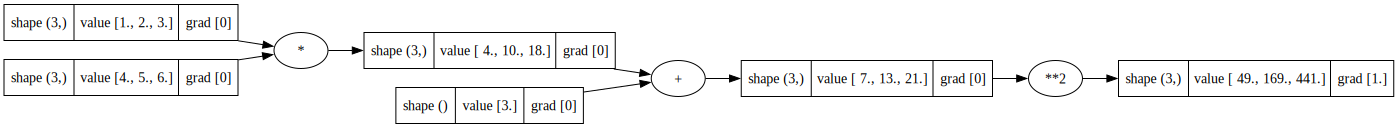

In [15]:

c.grad = 1.0
draw_dot(c)

In [16]:
a  = 10
b =  5

a * (b**-1)

2.0

In [17]:
def add(x: int, y: int) -> int:
    return x + y

add("hello", "world")

'helloworld'

In [18]:
import torch 

a = torch.tensor([2,34,5])
b = 5

a.__add__(b)

tensor([ 7, 39, 10])

In [19]:
a = np.array([1,23,4])
a.size

3